In [2]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns

In [5]:
df = pd.read_csv('Datasets/email_data.csv')
df

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\nth...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\n( see a...",0
2,3624,ham,"Subject: neon retreat\nho ho ho , we ' re arou...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\nthis deal is to ...,0
...,...,...,...,...
5166,1518,ham,Subject: put the 10 on the ft\nthe transport v...,0
5167,404,ham,Subject: 3 / 4 / 2000 and following noms\nhpl ...,0
5168,2933,ham,Subject: calpine daily gas nomination\n>\n>\nj...,0
5169,1409,ham,Subject: industrial worksheets for august 2000...,0


Create a model that can predict/classify spam mails based upon the given historical data.

spam - 1 <br>
ham - 0 <br>

Target column - label <br>

Since target is categorical, it is a classification problem.


## EDA

In [6]:
# attributes

df.columns

# Unnamed: 0 is not needed

Index(['Unnamed: 0', 'label', 'text', 'label_num'], dtype='object')

In [7]:
# check the count/distribution of spam vs ham. This would be helpful in identifying imbalanced data.

df.value_counts('label_num')

label_num
0    3672
1    1499
Name: count, dtype: int64

In [8]:
df.value_counts('label_num', normalize=True) * 100

# 28% are spam mails

label_num
0    71.01141
1    28.98859
Name: proportion, dtype: float64

In [9]:
# Imbalanced Data

# Ideal -> 50/50
# Workable -> 60/40
# Improve -> 70/30

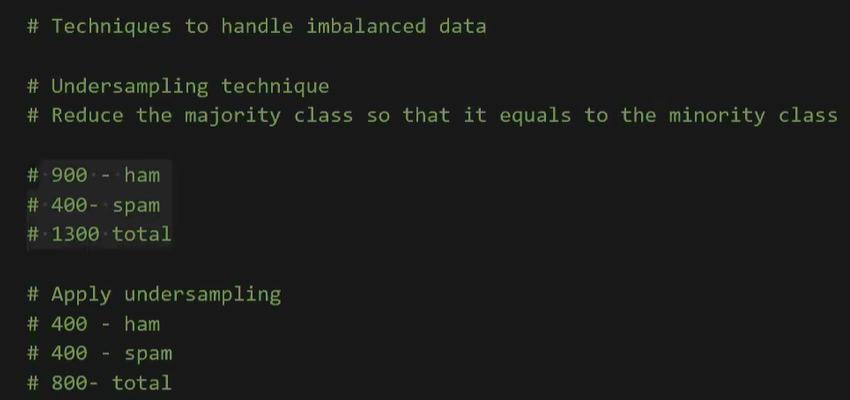


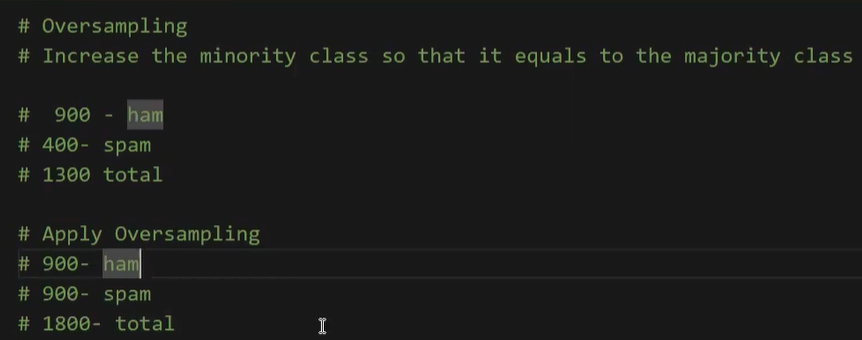


1 rows equals to 1 piece of learning to the model. Every unique row is 1 piece of learning to it. Duplicate rows don't give any learning to it.

<br>
Both the techniques are not ideal but Oversampling has some edge over Undersampling.


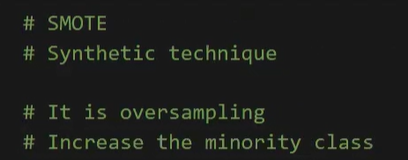

In [10]:
# remove the unwanted columns

df.drop('Unnamed: 0', axis = 1, inplace=True)

In [11]:
df

,label,text,label_num
0,ham,Subject: enron methanol ; meter # : 988291\nth...,0
1,ham,"Subject: hpl nom for january 9 , 2001\n( see a...",0
2,ham,"Subject: neon retreat\nho ho ho , we ' re arou...",0
3,spam,"Subject: photoshop , windows , office . cheap ...",1
4,ham,Subject: re : indian springs\nthis deal is to ...,0
...,...,...,...
5166,ham,Subject: put the 10 on the ft\nthe transport v...,0
5167,ham,Subject: 3 / 4 / 2000 and following noms\nhpl ...,0
5168,ham,Subject: calpine daily gas nomination\n>\n>\nj...,0
5169,ham,Subject: industrial worksheets for august 2000...,0


## Text Preprocessing

In [12]:
import re

In [13]:
# Text Cleaning

def text_cleaner(text):
    text = text.lower()
    text = re.sub(r'[^a-z \n]', '', text)
    text = re.sub(r'[\n]', ' ', text)
    text = re.sub(r'[ ]+',' ', text)
    return text;

In [14]:
df['clean_text'] = df.text.apply(text_cleaner)

In [15]:
df

,label,text,label_num,clean_text
0,ham,Subject: enron methanol ; meter # : 988291\nth...,0,subject enron methanol meter this is a follow ...
1,ham,"Subject: hpl nom for january 9 , 2001\n( see a...",0,subject hpl nom for january see attached file ...
2,ham,"Subject: neon retreat\nho ho ho , we ' re arou...",0,subject neon retreat ho ho ho we re around to ...
3,spam,"Subject: photoshop , windows , office . cheap ...",1,subject photoshop windows office cheap main tr...
4,ham,Subject: re : indian springs\nthis deal is to ...,0,subject re indian springs this deal is to book...
...,...,...,...,...
5166,ham,Subject: put the 10 on the ft\nthe transport v...,0,subject put the on the ft the transport volume...
5167,ham,Subject: 3 / 4 / 2000 and following noms\nhpl ...,0,subject and following noms hpl can t take the ...
5168,ham,Subject: calpine daily gas nomination\n>\n>\nj...,0,subject calpine daily gas nomination julie as ...
5169,ham,Subject: industrial worksheets for august 2000...,0,subject industrial worksheets for august activ...


In [16]:
print(df.text.iloc[0])

Subject: enron methanol ; meter # : 988291
this is a follow up to the note i gave you on monday , 4 / 3 / 00 { preliminary
flow data provided by daren } .
please override pop ' s daily volume { presently zero } to reflect daily
activity you can obtain from gas control .
this change is needed asap for economics purposes .


In [17]:
print(df.clean_text.iloc[0])

subject enron methanol meter this is a follow up to the note i gave you on monday preliminary flow data provided by daren please override pop s daily volume presently zero to reflect daily activity you can obtain from gas control this change is needed asap for economics purposes 


In [18]:
text='Hello                everyone'
text_cleaner(text)

'hello everyone'

In [19]:
# * -> Match all the occurence if the patter is found.
#     Return empty string if the patter is not found.

# + -> Match all the occurence if the patter is found.
#     Return None if the patter is not found.

In [20]:
text='He#llo####friends##!'

for i in re.finditer(r'[#]+',text):
    print(i)

<re.Match object; span=(2, 3), match='#'>
<re.Match object; span=(6, 10), match='####'>
<re.Match object; span=(17, 19), match='##'>


In [21]:
text='He#llo####friends##!'

for i in re.finditer(r'[#]*',text):
    print(i)

<re.Match object; span=(0, 0), match=''>
<re.Match object; span=(1, 1), match=''>
<re.Match object; span=(2, 3), match='#'>
<re.Match object; span=(3, 3), match=''>
<re.Match object; span=(4, 4), match=''>
<re.Match object; span=(5, 5), match=''>
<re.Match object; span=(6, 10), match='####'>
<re.Match object; span=(10, 10), match=''>
<re.Match object; span=(11, 11), match=''>
<re.Match object; span=(12, 12), match=''>
<re.Match object; span=(13, 13), match=''>
<re.Match object; span=(14, 14), match=''>
<re.Match object; span=(15, 15), match=''>
<re.Match object; span=(16, 16), match=''>
<re.Match object; span=(17, 19), match='##'>
<re.Match object; span=(19, 19), match=''>
<re.Match object; span=(20, 20), match=''>


In [22]:
df.head()

,label,text,label_num,clean_text
0,ham,Subject: enron methanol ; meter # : 988291\nth...,0,subject enron methanol meter this is a follow ...
1,ham,"Subject: hpl nom for january 9 , 2001\n( see a...",0,subject hpl nom for january see attached file ...
2,ham,"Subject: neon retreat\nho ho ho , we ' re arou...",0,subject neon retreat ho ho ho we re around to ...
3,spam,"Subject: photoshop , windows , office . cheap ...",1,subject photoshop windows office cheap main tr...
4,ham,Subject: re : indian springs\nthis deal is to ...,0,subject re indian springs this deal is to book...


## Tokenisation

In [23]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [24]:
lem = WordNetLemmatizer()

In [25]:
def tokeniser(text):
    
    def tag_cleaner(tag):
        if (tag.startswith('V')):
            return 'v'
        elif (tag.startswith('J')):
            return 'a'
        elif (tag.startswith('R')):
            return 'r'
        else:
            return 'n'
        
    tokens = word_tokenize(text)
    cleaned_tokens = [token for token in tokens if token not in stopwords.words('english')]
    tokens_with_tags = nltk.pos_tag(cleaned_tokens)
    
    lemmetised_tokens = []
    for token,tag in tokens_with_tags:
        new_tag = tag_cleaner(tag)
        lemmetised_tokens.append(lem.lemmatize(token, new_tag))
    
    return ' '.join(lemmetised_tokens)

In [26]:
tokeniser("hello! how are you? I am really happier")

'hello ! ? I really happier'

In [27]:
df['lemmatised_text'] = df.clean_text.apply(tokeniser)

In [28]:
df

,label,text,label_num,clean_text,lemmatised_text
0,ham,Subject: enron methanol ; meter # : 988291\nth...,0,subject enron methanol meter this is a follow ...,subject enron methanol meter follow note give ...
1,ham,"Subject: hpl nom for january 9 , 2001\n( see a...",0,subject hpl nom for january see attached file ...,subject hpl nom january see attach file hplnol...
2,ham,"Subject: neon retreat\nho ho ho , we ' re arou...",0,subject neon retreat ho ho ho we re around to ...,subject neon retreat ho ho ho around wonderful...
3,spam,"Subject: photoshop , windows , office . cheap ...",1,subject photoshop windows office cheap main tr...,subject photoshop windows office cheap main tr...
4,ham,Subject: re : indian springs\nthis deal is to ...,0,subject re indian springs this deal is to book...,subject indian spring deal book teco pvr reven...
...,...,...,...,...,...
5166,ham,Subject: put the 10 on the ft\nthe transport v...,0,subject put the on the ft the transport volume...,subject put ft transport volume decrease contr...
5167,ham,Subject: 3 / 4 / 2000 and following noms\nhpl ...,0,subject and following noms hpl can t take the ...,subject follow noms hpl take extra mmcf weeken...
5168,ham,Subject: calpine daily gas nomination\n>\n>\nj...,0,subject calpine daily gas nomination julie as ...,subject calpine daily gas nomination julie men...
5169,ham,Subject: industrial worksheets for august 2000...,0,subject industrial worksheets for august activ...,subject industrial worksheet august activity a...


In [29]:
print(df.clean_text.iloc[0])
print(df.lemmatised_text.iloc[0])

subject enron methanol meter this is a follow up to the note i gave you on monday preliminary flow data provided by daren please override pop s daily volume presently zero to reflect daily activity you can obtain from gas control this change is needed asap for economics purposes 
subject enron methanol meter follow note give monday preliminary flow data provide daren please override pop daily volume presently zero reflect daily activity obtain gas control change need asap economics purpose


In [30]:
dict(zip(df.clean_text.iloc[0].split(" "), df.lemmatised_text.iloc[0].split(" ")))

{'subject': 'subject',
 'enron': 'enron',
 'methanol': 'methanol',
 'meter': 'meter',
 'this': 'follow',
 'is': 'note',
 'a': 'give',
 'follow': 'monday',
 'up': 'preliminary',
 'to': 'flow',
 'the': 'data',
 'note': 'provide',
 'i': 'daren',
 'gave': 'please',
 'you': 'override',
 'on': 'pop',
 'monday': 'daily',
 'preliminary': 'volume',
 'flow': 'presently',
 'data': 'zero',
 'provided': 'reflect',
 'by': 'daily',
 'daren': 'activity',
 'please': 'obtain',
 'override': 'gas',
 'pop': 'control',
 's': 'change',
 'daily': 'need',
 'volume': 'asap',
 'presently': 'economics',
 'zero': 'purpose'}

## Text Vectorisation

In [31]:
vectorizer = TfidfVectorizer()

In [32]:
text_vector = vectorizer.fit_transform(df.lemmatised_text).toarray()
text_vector

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5171, 41933))

In [ ]:
df.shape, text_vector.shape
# rows => total number of email subjects
# columnms => vocab - unique words from all the texts

((5171, 5), (5171, 41933))

In [34]:
vectorizer.get_feature_names_out()

array(['aa', 'aaa', 'aabda', ..., 'zzocb', 'zzso', 'zzsyt'],
      shape=(41933,), dtype=object)

In [42]:
documents = [doc for doc in df.lemmatised_text.str.split()]
len(documents)

5171

In [43]:
total_words = []
for doc in documents:
    #print(wordList)
    for word in doc:
            total_words.append(word)

In [46]:
print(len(total_words)) # total no. of words from all documents
print(len(set(total_words))) # total no. of unique words

503338
41957


In [57]:
features = pd.DataFrame(text_vector)
features # means the input data

,0,1,2,3,4,5,6,7,8,9,...,41923,41924,41925,41926,41927,41928,41929,41930,41931,41932
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5166,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5167,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5168,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5169,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [59]:
df['label'].unique()

array(['ham', 'spam'], dtype=object)

In [60]:
df['target'] = df.label.map({'ham': 0, 'spam': 1})

In [62]:
df.target.shape

(5171,)